<img src="https://s8.hostingkartinok.com/uploads/images/2018/08/308b49fcfbc619d629fe4604bceb67ac.jpg" width=500, height=450>
<h3 style="text-align: center;"><b>Физтех-Школа Прикладной математики и информатики (ФПМИ) МФТИ</b></h3>

---

***Some parts of the notebook are almost the copy of [ mmta-team course](https://github.com/mmta-team/mmta_fall_2020). Special thanks to mmta-team for making them publicly available. [Original notebook](https://github.com/mmta-team/mmta_fall_2020/blob/master/tasks/01_word_embeddings/task_word_embeddings.ipynb).***

<b> Прочитайте семинар, пожалуйста, для успешного выполнения домашнего задания. В конце ноутка напишите свой вывод. Работа без вывода оценивается ниже.

## Задача поиска схожих по смыслу предложений

Мы будем ранжировать вопросы [StackOverflow](https://stackoverflow.com) на основе семантического векторного представления

До этого в курсе не было речи про задачу ранжировния, поэтому введем математическую формулировку

## Задача ранжирования(Learning to Rank)

* $X$ - множество объектов
* $X^l = \{x_1, x_2, ..., x_l\}$ - обучающая выборка
<br>На обучающей выборке задан порядок между некоторыми элементами, то есть нам известно, что некий объект выборки более релевантный для нас, чем другой:
* $i \prec j$ - порядок пары индексов объектов на выборке $X^l$ c индексами $i$ и $j$
### Задача:
построить ранжирующую функцию $a$ : $X \rightarrow R$ такую, что
$$i \prec j \Rightarrow a(x_i) < a(x_j)$$

<img src="https://d25skit2l41vkl.cloudfront.net/wp-content/uploads/2016/12/Featured-Image.jpg" width=500, height=450>

### Embeddings

Будем использовать предобученные векторные представления слов на постах Stack Overflow.<br>
[A word2vec model trained on Stack Overflow posts](https://github.com/vefstathiou/SO_word2vec)

In [1]:
!wget https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1

--2026-03-18 15:59:44--  https://zenodo.org/record/1199620/files/SO_vectors_200.bin?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.185.43.153, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1199620/files/SO_vectors_200.bin [following]
--2026-03-18 15:59:45--  https://zenodo.org/records/1199620/files/SO_vectors_200.bin
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 1453905423 (1.4G) [application/octet-stream]
Saving to: ‘SO_vectors_200.bin?download=1.1’

SO_vectors_200.bin? 100%[===================>]   1.35G  14.8MB/s    in 94s     

2026-03-18 16:01:19 (14.7 MB/s) - ‘SO_vectors_200.bin?download=1.1’ saved [1453905423/1453905423]



In [2]:
!pip install gensim

In [3]:
from gensim.models.keyedvectors import KeyedVectors
wv_embeddings = KeyedVectors.load_word2vec_format("SO_vectors_200.bin?download=1", binary=True)

#### Как пользоваться этими векторами?

Посмотрим на примере одного слова, что из себя представляет embedding

In [4]:
word = 'dog'
if word in wv_embeddings:
    print(wv_embeddings[word].dtype, wv_embeddings[word].shape)

float32 (200,)


In [5]:
print(f"Num of words: {len(wv_embeddings.index_to_key)}")

Num of words: 1787145


Найдем наиболее близкие слова к слову `dog`:

#### ***Вопрос 1:***
* Входит ли слово `cat` в топ-5 близких слов к слову `dog`? Какое место оно занимает?


Проверяем, входит ли слово 'cat' в топ-5

In [6]:
# method most_simmilar
wv_embeddings.most_similar('dog', topn=5)

[('animal', 0.8564180135726929),
 ('dogs', 0.7880866527557373),
 ('mammal', 0.7623804211616516),
 ('cats', 0.7621253728866577),
 ('animals', 0.760793924331665)]

Проверяем, какое место занимает слово 'cat'

In [7]:
top_list = wv_embeddings.most_similar('dog', topn=1000)
for i in range(len(top_list)):
  if top_list[i][0] == 'cat':
    print(i+1)
    break

26


***Ваш ответ:*** 'cat' не входит в топ-5 ближайших слов к 'dog'. Слово 'cat' занимает 26-е место

### Векторные представления текста

Перейдем от векторных представлений отдельных слов к векторным представлениям вопросов, как к **среднему** векторов всех слов в вопросе. Если для какого-то слова нет предобученного вектора, то его нужно пропустить. Если вопрос не содержит ни одного известного слова, то нужно вернуть нулевой вектор.

In [8]:
import numpy as np
import re
# you can use your tokenizer
# for example, from nltk.tokenize import WordPunctTokenizer
class MyTokenizer:
    def __init__(self):
        pass
    def tokenize(self, text):
        return re.findall(r'\w+', text)
tokenizer = MyTokenizer()

Пока что оставляю самый простой вариант для токенайзера и, соответственно, для векторного представления предложения

In [9]:
def question_to_vec(question, embeddings, tokenizer, dim=200):
    """
        question: строка
        embeddings: наше векторное представление
        dim: размер любого вектора в нашем представлении

        return: векторное представление для вопроса
    """
    tokens = tokenizer.tokenize(question)

    question_embedding = np.zeros(dim)
    for token in tokens:
        if token in embeddings:
            question_embedding += embeddings[token]

    return question_embedding / len(tokens)

Теперь у нас есть метод для создания векторного представления любого предложения.

#### ***Вопрос 2:***

* Какая третья (с индексом 2) компонента вектора предложения `I love neural networks` (округлите до 2 знаков после запятой)?

In [10]:
# Предложение
question = "I love neural networks"

question_to_vec(question, wv_embeddings, tokenizer)[2]

np.float64(-0.964059129357338)

***Ваш ответ:*** -0.96

### Оценка близости текстов

Представим, что мы используем идеальные векторные представления слов. Тогда косинусное расстояние между дублирующими предложениями должно быть меньше, чем между случайно взятыми предложениями.

Сгенерируем для каждого из $N$ вопросов $R$ случайных отрицательных примеров и примешаем к ним также настоящие дубликаты. Для каждого вопроса будем ранжировать с помощью нашей модели $R + 1$ примеров и смотреть на позицию дубликата. Мы хотим, чтобы дубликат был первым в ранжированном списке.

#### Hits@K
Первой простой метрикой будет количество корректных попаданий для какого-то $K$:
$$ \text{Hits@K} = \frac{1}{N}\sum_{i=1}^N \, [rank\_q_i^{'} \le K],$$
* $\begin{equation*}
[x < 0 ] \equiv
 \begin{cases}
   1, &x < 0\\
   0, &x \geq 0
 \end{cases}
\end{equation*}$ - индикаторная функция
* $q_i$ - $i$-ый вопрос
* $q_i^{'}$ - его дубликат
* $rank\_q_i^{'}$ - позиция дубликата в ранжированном списке ближайших предложений для вопроса $q_i$.

Hits@K  измеряет долю вопросов, для которых правильный ответ попал в топ-K позиций среди отранжированных кандидатов.

#### DCG@K
Второй метрикой будет упрощенная DCG метрика, учитывающая порядок элементов в списке путем домножения релевантности элемента на вес равный обратному логарифму номера позиции::
$$ \text{DCG@K} = \frac{1}{N} \sum_{i=1}^N\frac{1}{\log_2(1+rank\_q_i^{'})}\cdot[rank\_q_i^{'} \le K],$$
С такой метрикой модель штрафуется за большой ранк корректного ответа.

DCG@K  измеряет качество ранжирования, учитывая не только факт наличия правильного ответа в топ-K, но и ***его точную позицию***.

<img src='https://hsto.org/files/1c5/edf/dee/1c5edfdeebce4b71a86bdf986d9f88f2.jpg' width=400, height=200>

#### Пример оценок

Вычислим описанные выше метрики для игрушечного примера.
Пусть
* $N = 1$, $R = 3$
* <font color='green'>"Что такое python?"</font> - вопрос $q_1$
* <font color='red'>"Что такое язык python?"</font> - его дубликат $q_i^{'}$

Пусть модель выдала следующий ранжированный список кандидатов:

1. "Как изучить с++?"
2. <font color='red'>"Что такое язык python?"</font>
3. "Хочу учить Java"
4. "Не понимаю Tensorflow"

$\Rightarrow rank\_q_i^{'} = 2$

Вычислим метрику *Hits@K* для *K = 1, 4*:

- [K = 1] $\text{Hits@1} =  [rank\_q_i^{'} \le 1]$

Проверяем условие $ \text{rank}_{q'_1} \leq 1 $: ***условие неверно***.

Следовательно, $[\text{rank}_{q'_1} \leq 1] = 0$.

- [K = 4] $\text{Hits@4} =  [rank\_q_i^{'} \le 4] = 1$

Проверяем условие $ \text{rank}_{q'_1} \leq 4 $: ***условие верно***.

Вычислим метрику *DCG@K* для *K = 1, 4*:
- [K = 1] $\text{DCG@1} = \frac{1}{\log_2(1+2)}\cdot[2 \le 1] = 0$
- [K = 4] $\text{DCG@4} = \frac{1}{\log_2(1+2)}\cdot[2 \le 4] = \frac{1}{\log_2{3}}$

#### ***Вопрос 3***:
* Вычислите `DCG@10`, если $rank\_q_i^{'} = 9$(округлите до одного знака после запятой)



In [11]:
1./np.log2(1+9)

np.float64(0.3010299956639812)

***Ваш ответ:*** 0.3

#### Более сложный пример оценок

Рассмотрим пример с $ N > 1 $, где $ N = 3 $ (три вопроса) и для каждого вопроса заданы позиции их дубликатов. Вычислим метрики **Hits@K** для разных значений $ K $.

---

- $ N = 3 $: Три вопроса ($ q_1, q_2, q_3 $).
- Для каждого вопроса известна позиция его дубликата ($ \text{rank}_{q'_i} $):
  - $ \text{rank}_{q'_1} = 2 $,
  - $ \text{rank}_{q'_2} = 5 $,
  - $ \text{rank}_{q'_3} = 1 $.

Мы будем вычислять **Hits@K** для $ K = 1, 5 $.

---

**Для $ K = 1 $:**

Подставим значения:
$$
\text{Hits@1} = \frac{1}{3} \cdot \left( [\text{rank}_{q'_1} \leq 1] + [\text{rank}_{q'_2} \leq 1] + [\text{rank}_{q'_3} \leq 1] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 1 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 1 $ → $ 1 $.

Сумма:
$$
\text{Hits@1} = \frac{1}{3} \cdot (0 + 0 + 1) = \frac{1}{3}.
$$

$$
\boxed{\text{Hits@1} = \frac{1}{3}}.
$$

---

**Для $ K = 5 $:**

Подставим значения:
$$
\text{Hits@5} = \frac{1}{3} \cdot \left( [\text{rank}_{q'_1} \leq 5] + [\text{rank}_{q'_2} \leq 5] + [\text{rank}_{q'_3} \leq 5] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 5 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 5 $ → $ 1 $.

Сумма:
$$
\text{Hits@5} = \frac{1}{3} \cdot (1 + 1 + 1) = 1.
$$

$$
\boxed{\text{Hits@5} = 1}.
$$

Теперь вычислим метрику **DCG@K** для того же примера, где $ N = 3 $ (три вопроса), и для каждого вопроса известна позиция его дубликата ($ \text{rank}_{q'_i} $):

- $ \text{rank}_{q'_1} = 2 $,
- $ \text{rank}_{q'_2} = 5 $,
- $ \text{rank}_{q'_3} = 1 $.

Мы будем вычислять **DCG@K** для $ K = 1, 5 $.

---
**Для $ K = 1 $:**
Подставим значения:
$$
\text{DCG@1} = \frac{1}{3} \cdot \left( \frac{1}{\log_2(1 + \text{rank}_{q'_1})} \cdot [\text{rank}_{q'_1} \leq 1] + \frac{1}{\log_2(1 + \text{rank}_{q'_2})} \cdot [\text{rank}_{q'_2} \leq 1] + \frac{1}{\log_2(1 + \text{rank}_{q'_3})} \cdot [\text{rank}_{q'_3} \leq 1] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 1 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \not\leq 1 $ → $ 0 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 1 $ → $ 1 $.

Сумма:
$$
\text{DCG@1} = \frac{1}{3} \cdot (0 + 0 + 1) = \frac{1}{3}.
$$
$$
\boxed{\text{DCG@1} = \frac{1}{3}}.
$$

---


**Для $ K = 5 $:**
Подставим значения:
$$
\text{DCG@5} = \frac{1}{3} \cdot \left( \frac{1}{\log_2(1 + \text{rank}_{q'_1})} \cdot [\text{rank}_{q'_1} \leq 5] + \frac{1}{\log_2(1 + \text{rank}_{q'_2})} \cdot [\text{rank}_{q'_2} \leq 5] + \frac{1}{\log_2(1 + \text{rank}_{q'_3})} \cdot [\text{rank}_{q'_3} \leq 5] \right).
$$

Проверяем условие $ \text{rank}_{q'_i} \leq 5 $ для каждого вопроса:
- $ \text{rank}_{q'_1} = 2 $ → $ 2 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_2} = 5 $ → $ 5 \leq 5 $ → $ 1 $,
- $ \text{rank}_{q'_3} = 1 $ → $ 1 \leq 5 $ → $ 1 $.

Сумма:
$$
\text{DCG@5} = \frac{1}{3} \cdot (0.631 + 0.387 + 1) = \frac{1}{3} \cdot 2.018 \approx 0.673.
$$

$$
\boxed{\text{DCG@5} \approx 0.673}.
$$

#### ***Вопрос 4:***
* Найдите максимум `Hits@47 - DCG@1`?



max(Hits@47 - DCG@1) = max(Hits@47) - min(DCG@1) = 1 - 0 = 1

***Ваш ответ:*** 1

### HITS\_COUNT и DCG\_SCORE

Каждая функция имеет два аргумента: $dup\_ranks$ и $k$.

$dup\_ranks$ является списком, который содержит рейтинги дубликатов (их позиции в ранжированном списке).

К примеру для <font color='red'>"Что такое язык python?"</font> $dup\_ranks = [2]$.

In [12]:
def hits_count(dup_ranks, k):
    """
        dup_ranks: list индексов дубликатов
        k: пороговое значение для ранга
        result: вернуть Hits@k
    """
    ranks_arr = np.array(dup_ranks)
    return float(np.mean(ranks_arr <= k))

In [13]:
dup_ranks = [2]

k = 1
hits_value = hits_count(dup_ranks, k)
print(f"Hits@1 = {hits_value}")

k = 4
hits_value = hits_count(dup_ranks, k)
print(f"Hits@4 = {hits_value}")

Hits@1 = 0.0
Hits@4 = 1.0


In [14]:
def dcg_score(dup_ranks, k):
    """
        dup_ranks: list индексов дубликатов
        k: пороговое значение для ранга
        result: вернуть DCG@k
    """
    ranks_arr = np.array(dup_ranks)
    scores = np.where(ranks_arr <= k, 1.0 / np.log2(1 + ranks_arr), 0.0)
    return float(np.mean(scores))

In [15]:
# Пример списка позиций дубликатов
dup_ranks = [2]

# Вычисляем DCG@1
dcg_value = dcg_score(dup_ranks, k=1)
print(f"DCG@1 = {dcg_value:.3f}")

# Вычисляем DCG@4
dcg_value = dcg_score(dup_ranks, k=4)
print(f"DCG@4 = {dcg_value:.3f}")

DCG@1 = 0.000
DCG@4 = 0.631


Протестируем функции. Пусть $N = 1$, то есть один эксперимент. Будем искать копию вопроса и оценивать метрики.

In [16]:
import pandas as pd

In [17]:
copy_answers = ["How does the catch keyword determine the type of exception that was thrown",]

# наши кандидаты
candidates_ranking = [["How Can I Make These Links Rotate in PHP",
                       "How does the catch keyword determine the type of exception that was thrown", # вот копия вопроса, на 2м месте
                       "NSLog array description not memory address",
                       "PECL_HTTP not recognised php ubuntu"],]

# dup_ranks — позиции наших копий, так как эксперимент один, то этот массив длины 1
dup_ranks = [2]

# вычисляем метрику для разных k
print('Ваш ответ HIT:', [hits_count(dup_ranks, k) for k in range(1, 5)])
print('Ваш ответ DCG:', [round(dcg_score(dup_ranks, k), 5) for k in range(1, 5)])

Ваш ответ HIT: [0.0, 1.0, 1.0, 1.0]
Ваш ответ DCG: [0.0, 0.63093, 0.63093, 0.63093]


У вас должно получиться

In [18]:
# correct_answers - метрика для разных k
correct_answers = pd.DataFrame([[0, 1, 1, 1], [0, 1 / (np.log2(3)), 1 / (np.log2(3)), 1 / (np.log2(3))]],
                               index=['HITS', 'DCG'], columns=range(1,5))
correct_answers

,1,2,3,4
HITS,0,1.00000,1.00000,1.00000
DCG,0,0.63093,0.63093,0.63093


### Данные
[arxiv link](https://drive.google.com/file/d/1QqT4D0EoqJTy7v9VrNCYD-m964XZFR7_/edit)

`train.tsv` - выборка для обучения.<br> В каждой строке через табуляцию записаны: **<вопрос>, <похожий вопрос>**

`validation.tsv` - тестовая выборка.<br> В каждой строке через табуляцию записаны: **<вопрос>, <похожий вопрос>, <отрицательный пример 1>, <отрицательный пример 2>, ...**

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
!unzip "/content/drive/MyDrive/Colab Notebooks/stackoverflow_similar_questions.zip"

Archive:  /content/drive/MyDrive/Colab Notebooks/stackoverflow_similar_questions.zip
replace data/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data/.DS_Store          
replace __MACOSX/data/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: __MACOSX/data/._.DS_Store  
replace data/train.tsv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data/train.tsv          
replace data/validation.tsv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: data/validation.tsv     y



Считайте данные.

In [21]:
def read_corpus(filename):
    data = []
    with open(filename, encoding='utf-8') as file:
        for line in file:
            data.append(line.strip().split('\t'))
    return data

Нам понадобиться только файл validation.

In [22]:
validation_data = read_corpus('./data/validation.tsv')

Кол-во строк

In [23]:
len(validation_data)

3760

Размер нескольких первых строк

In [24]:
for i in range(25):
    print(i + 1, len(validation_data[i]))

1 1001
2 1001
3 1001
4 1001
5 1001
6 1001
7 1001
8 1001
9 1001
10 1001
11 1001
12 1001
13 1001
14 1001
15 1001
16 1001
17 1001
18 1001
19 1001
20 1001
21 1001
22 1001
23 1001
24 1001
25 1001


### Ранжирование без обучения

Реализуйте функцию ранжирования кандидатов на основе косинусного расстояния. Функция должна по списку кандидатов вернуть отсортированный список пар (позиция в исходном списке кандидатов, кандидат). При этом позиция кандидата в полученном списке является его рейтингом (первый - лучший). Например, если исходный список кандидатов был [a, b, c], и самый похожий на исходный вопрос среди них - c, затем a, и в конце b, то функция должна вернуть список **[(2, c), (0, a), (1, b)]**.

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
from copy import deepcopy

Более сложный токенайзер:
- убираем из предложения всё, кроме букв, цифр и пробелов
- с удалением стоп-слов
- с возможностью лемматизации

In [26]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopWords = set(stopwords.words('english'))

import spacy
nlp = spacy.load('en_core_web_sm')

class MyTokenizer_upd:
  def __init__(self, use_lemmatization=True):
    self.use_lemmatization = use_lemmatization

  def tokenize(self, text):
    text_upd = re.sub(r'[^\w\s]', '', text).lower()
    tokens = re.findall(r'\w+', text_upd)

    tokens = [word for word in tokens if word not in stopWords]

    if self.use_lemmatization:
      spacy_results = nlp(' '.join(tokens))
      tokens = [token.lemma_ for token in spacy_results]

    return tokens

tokenizer_upd_with_lemmatization = MyTokenizer_upd()
tokenizer_upd_without_lemmatization = MyTokenizer_upd(use_lemmatization=False)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
def rank_candidates(question, candidates, embeddings, tokenizer, dim=200):
    """
        question: строка
        candidates: массив строк(кандидатов) [a, b, c]
        result: пары (начальная позиция, кандидат) [(2, c), (0, a), (1, b)]
    """
    q_vec = question_to_vec(question, embeddings, tokenizer).reshape(1, dim)

    scored = []
    for idx, candidate in enumerate(candidates):
        cand_vec = question_to_vec(candidate, embeddings, tokenizer).reshape(1, dim)
        sim = cosine_similarity(q_vec, cand_vec)[0][0]
        scored.append((sim, idx, candidate))

    scored.sort(key=lambda x: x[0], reverse=True)
    return [(idx, cand) for _, idx, cand in scored]

Протестируйте работу функции на примерах ниже. Пусть $N=2$, то есть два эксперимента

In [28]:
questions = ['converting string to list', 'Sending array via Ajax fails']

candidates = [['Convert Google results object (pure js) to Python object', # первый эксперимент
               'C# create cookie from string and send it',
               'How to use jQuery AJAX for an outside domain?'],

              ['Getting all list items of an unordered list in PHP',      # второй эксперимент
               'WPF- How to update the changes in list item of a list',
               'select2 not displaying search results']]

Результат для самого простого токенайзера

In [29]:
for question, q_candidates in zip(questions, candidates):
        ranks = rank_candidates(question, q_candidates, wv_embeddings, tokenizer)
        print(ranks)
        print()

[(1, 'C# create cookie from string and send it'), (0, 'Convert Google results object (pure js) to Python object'), (2, 'How to use jQuery AJAX for an outside domain?')]

[(1, 'WPF- How to update the changes in list item of a list'), (0, 'Getting all list items of an unordered list in PHP'), (2, 'select2 not displaying search results')]



Токенайзер без лемматизации

In [30]:
for question, q_candidates in zip(questions, candidates):
        ranks = rank_candidates(question, q_candidates, wv_embeddings, tokenizer_upd_without_lemmatization)
        print(ranks)
        print()

[(1, 'C# create cookie from string and send it'), (0, 'Convert Google results object (pure js) to Python object'), (2, 'How to use jQuery AJAX for an outside domain?')]

[(0, 'Getting all list items of an unordered list in PHP'), (2, 'select2 not displaying search results'), (1, 'WPF- How to update the changes in list item of a list')]



Токенайзер с лемматизацией

In [31]:
for question, q_candidates in zip(questions, candidates):
        ranks = rank_candidates(question, q_candidates, wv_embeddings, tokenizer_upd_with_lemmatization)
        print(ranks)
        print()

[(1, 'C# create cookie from string and send it'), (0, 'Convert Google results object (pure js) to Python object'), (2, 'How to use jQuery AJAX for an outside domain?')]

[(0, 'Getting all list items of an unordered list in PHP'), (2, 'select2 not displaying search results'), (1, 'WPF- How to update the changes in list item of a list')]



Видим, что ответы для разных токенайзеров отличаются только для второго вопроса, при этом лемматизация не вносит существенных изменений, достаточно удаления стоп-слов и символов

Для первого экперимента вы можете полностью сравнить ваши ответы и правильные ответы. Но для второго эксперимента два ответа на кандидаты будут <b>скрыты</b>(*)

In [ ]:
# должно вывести
results = [[(1, 'C# create cookie from string and send it'),
            (0, 'Convert Google results object (pure js) to Python object'),
            (2, 'How to use jQuery AJAX for an outside domain?')],
           [(*, 'Getting all list items of an unordered list in PHP'), #скрыт
            (*, 'select2 not displaying search results'), #скрыт
            (*, 'WPF- How to update the changes in list item of a list')]] #скрыт

Последовательность начальных индексов вы должны получить `для эксперимента 1`  1, 0, 2.

#### ***Вопрос 5:***
* Какую последовательность начальных индексов вы получили `для эксперимента 2`(перечисление без запятой и пробелов, например, `102` для первого эксперимента?


***Ваш ответ:*** 021

Теперь мы можем оценить качество нашего метода. Запустите следующие два блока кода для получения результата. Обратите внимание, что вычисление расстояния между векторами занимает некоторое время (примерно 10 минут). Можете взять для validation 1000 примеров.

In [32]:
from tqdm.notebook import tqdm

Беру токенайзер без лемматизации, чтобы считалось быстрее

In [ ]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, wv_embeddings, tokenizer_upd_without_lemmatization)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

In [ ]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

Из формул выше можно понять, что

- $ \text{Hits@K} $ **монотонно неубывающая функция** $ K $, которая стремится к 1 при $ K \to \infty $.

- $ \text{DCG@K} $ **монотонно неубывающая функция** $ K $, но рост замедляется с увеличением $ K $ из-за убывания веса $ \frac{1}{\log_2(1 + \text{rank}_{q'_i})} $.

### Эмбеддинги, обученные на корпусе похожих вопросов

In [35]:
train_data = read_corpus('./data/train.tsv')

Улучшите качество модели.<br>Склеим вопросы в пары и обучим на них модель Word2Vec из gensim. Выберите размер window. Объясните свой выбор.

***Рассмотрим подробнее*** данное склеивание.

1. Каждая строка из train_data разбивается на вопрос (question) и список кандидатов.

2. Для каждого кандидата вопрос склеивается с ним в одну строку.

3. Склеенная строка (combined_text) токенизируется, и полученный список токенов добавляется в общий корпус (corpus).

***Пример***

    Вопрос: "What is Python?"
    Кандидаты: ["Python is a programming language", "Java is another language"]
    Склеенные строки:
        "What is Python? Python is a programming language"
        "What is Python? Java is another language"
         
    Токенизированные списки:
        ['what', 'is', 'python', 'python', 'is', 'a', 'programming', 'language']
        ['what', 'is', 'python', 'java', 'is', 'another', 'language']
         
     

In [36]:
train_data[111258]

['Determine if the device is a smartphone or tablet?',
 'Change imageView params in all cards together']

In [ ]:
# Создаем общий корпус текстов
corpus = []

for item in tqdm(train_data):
  all_tokens = tokenizer_upd_without_lemmatization.tokenize(item[0]) + tokenizer_upd_without_lemmatization.tokenize(item[1])
  corpus.append(all_tokens)

In [39]:
corpus[111258]

['determine',
 'device',
 'smartphone',
 'tablet',
 'change',
 'imageview',
 'params',
 'cards',
 'together']

Посмотрим на распределение частотности слов

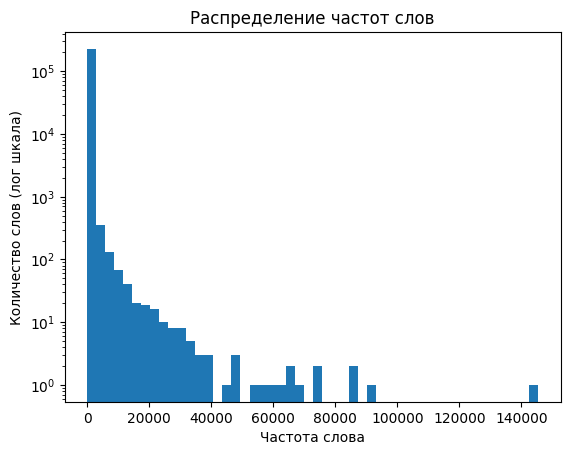

Слов с частотой 1: 131896 (57.74%)
Слов с частотой 2: 31848 (13.94%)
Слов с частотой >= 3: 64693 (28.32%)


In [45]:
from collections import Counter
import matplotlib.pyplot as plt

word_counts = Counter(word for text in corpus for word in text)
frequencies = list(word_counts.values())

plt.hist(frequencies, bins=50, log=True)
plt.xlabel('Частота слова')
plt.ylabel('Количество слов (лог шкала)')
plt.title('Распределение частот слов')
plt.show()

freq1 = sum(1 for f in frequencies if f == 1)
freq2 = sum(1 for f in frequencies if f == 2)
freq3plus = sum(1 for f in frequencies if f >= 3)
total = freq1 + freq2 + freq3plus

percent1 = (freq1 / total) * 100
percent2 = (freq2 / total) * 100
percent3plus = (freq3plus / total) * 100

print(f"Слов с частотой 1: {freq1} ({round(percent1, 2)}%)")
print(f"Слов с частотой 2: {freq2} ({round(percent2, 2)}%)")
print(f"Слов с частотой >= 3: {freq3plus} ({round(percent3plus, 2)}%)")

Я выбраю min_count=2, потому что анализ распределения частот слов в корпусе показал, что:
- почти 58% слов встречаются всего 1 раз, они не дадут качественных векторов
- слова с частотой 2 составляют 14% словаря и могут содержать важную редкую терминологию, которую жалко терять
- при пороге 2 мы сохраняем 42% словаря, убирая основной шум, но оставляя потенциально значимые редкие слова

Размер окна я выбираю равным 5, т.к. это стандартное значение, а в корпусе уже удалены стоп-слова, поэтому окно 5 захватывает именно смысловых соседей, а не служебные слова

In [46]:
from gensim.models import Word2Vec
embeddings_trained = Word2Vec(
    sentences=corpus,        # Корпус токенизированных текстов
    vector_size=200,         # Размерность векторов
    window=5,                # Размер окна контекста
    min_count=2,             # Минимальная частота слов
    workers=4                # Количество потоков
).wv

In [ ]:
wv_ranking = []
max_validation_examples = 1000
for i, line in enumerate(tqdm(validation_data)):
    if i == max_validation_examples:
        break
    q, *ex = line
    ranks = rank_candidates(q, ex, embeddings_trained, tokenizer_upd_without_lemmatization)
    wv_ranking.append([r[0] for r in ranks].index(0) + 1)

In [ ]:
for k in tqdm([1, 5, 10, 100, 500, 1000]):
    print("DCG@%4d: %.3f | Hits@%4d: %.3f" % (k, dcg_score(wv_ranking, k), k, hits_count(wv_ranking, k)))

### Замечание:
Решить эту задачу с помощью обучения полноценной нейронной сети будет вам предложено, как часть задания в одной из домашних работ по теме "Диалоговые системы".

Напишите свой вывод о полученных результатах.
* Какой принцип токенизации даёт качество лучше и почему?
* Помогает ли нормализация слов?
* Какие эмбеддинги лучше справляются с задачей и почему?
* Почему получилось плохое качество решения задачи?
* Предложите свой подход к решению задачи.

## Вывод:


- На мой взгляд, самый большой буст для токенизации дает устранение стоп-слов и различных символов (знаки пунктуации и пр)
- Нормализация слов помогает, но я пока попробовала только лемматизацию от spacy, она долгая. Думаю, что можно заменить лемматизацию на более быстрый стемминг без значительной потери качества
- Думаю, что на качество решения задачи повлияли несколько факторов:
    - усреднение векторов слов - таким образом теряем порядок слов, возможно имеет  смысл попробовать иной подход (например, tf-idf)
    - слова с частотой 2 дают нестабильные векторы, можно поварьировать параметр
    - то же касается размера окна, мы можем не захватывать дальние зависимости, имеет смысл попробовать разные варианты
    - можно попробовать использовать FastText вместо Word2Vec для лучшей обработки редких слов